In [4]:
# PROBLEM STATEMENT:
#Dream Housing Finance company deals in all home loans. They have a presence across all urban, semi-urban and rural areas.
#Customers first apply for a home loan after that company validates the customer’s eligibility for a loan. The company wants
# to automate the loan eligibility process (real-time) based on customer detail provided while filling out the online application form.
#@ These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History, and others
# To automate this process, they have given a problem to identify the customer segments, that are eligible for loan amounts so that
#they can specifically target these customers.

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
#classification algorithm
from sklearn.linear_model import LogisticRegression
#evaluation libraries
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score,classification_report
#KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier

In [6]:
#csv -coma separated values
filepath = Path.cwd() /'..'/'data'/'train_loan.csv'
data = pd.read_csv(filepath)


In [7]:
#copy original data for preprocessing
df=data.copy()

In [8]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Data analysis( data behaviour analysis)

Univariate analysis(single feature analysis)

In [9]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [10]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [11]:
df['ApplicantIncome'].dtypes

dtype('int64')

In [12]:
num_cols = [column for column in df.columns if df[column].dtypes != 'O']

In [13]:
df[num_cols]

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [14]:
#num_cols

In [15]:
df['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [16]:
df['Dependents'].nunique()

4

In [17]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [18]:
df['Dependents'].replace({'3+':3}, inplace=True)

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\679725573.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].replace({'3+':3}, inplace=True)


In [19]:
df.shape

(614, 13)

In [20]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [21]:
# discrete
df['Loan_Amount_Term'].nunique()

10

#univariate analysis of continuous numerical columns


C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

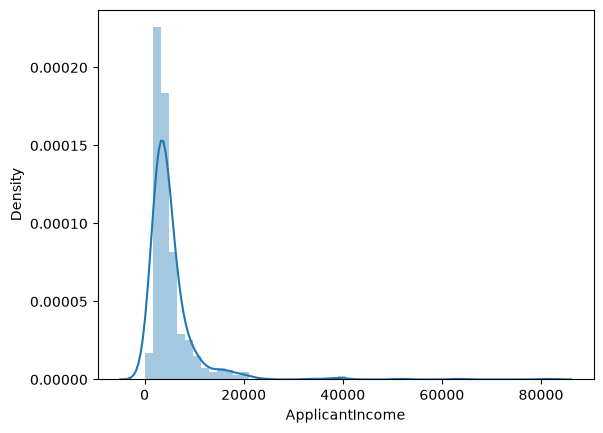

In [22]:
sns.distplot(df['ApplicantIncome'])

<Axes: ylabel='ApplicantIncome'>

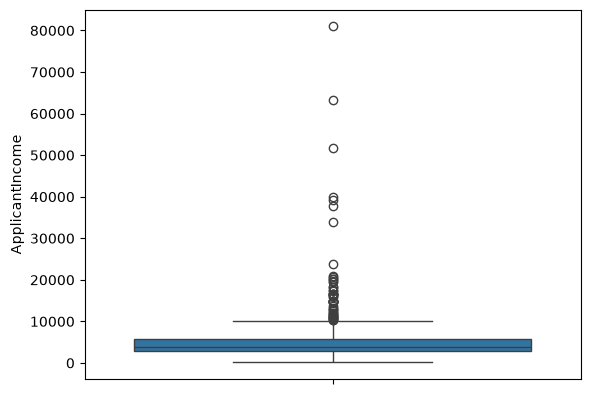

In [23]:
sns.boxplot(df['ApplicantIncome'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\467202043.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

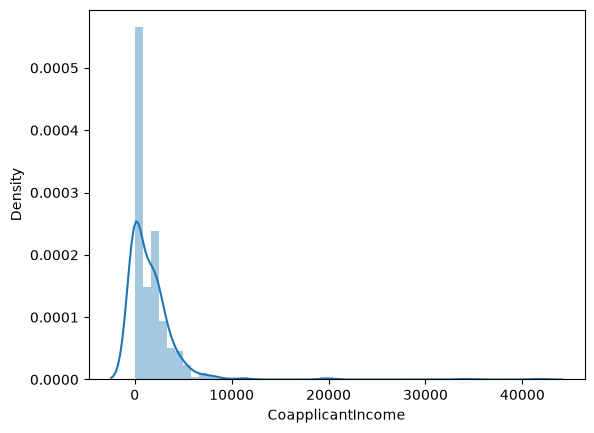

In [24]:
#we have seen there is extreem outliers in paalicantIncome so not to suggest mean ,take median
sns.distplot(df['CoapplicantIncome'])

<Axes: ylabel='CoapplicantIncome'>

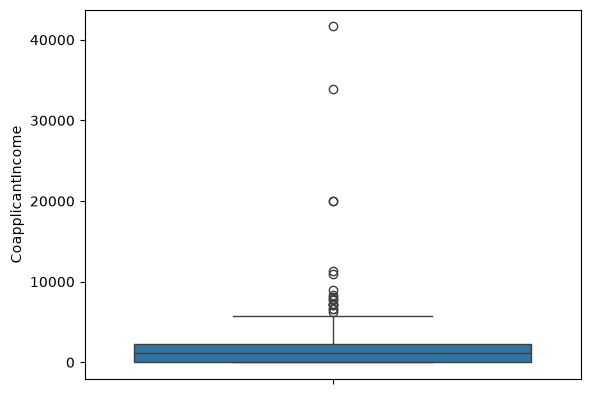

In [25]:
sns.boxplot(df['CoapplicantIncome'])

<Axes: ylabel='LoanAmount'>

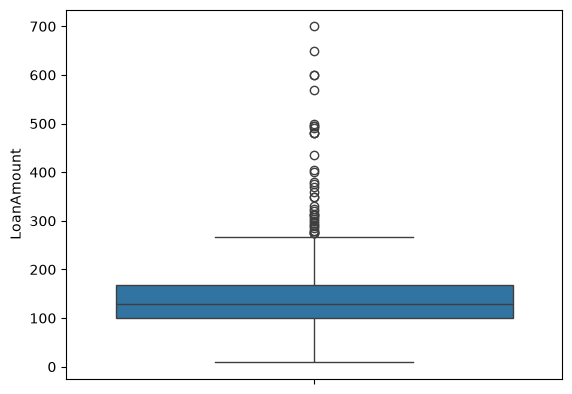

In [26]:
sns.boxplot(df['LoanAmount'])

#Univariate analysis of Discrete Numerical Columns

Cardinality check of the columns

<Axes: xlabel='Dependents', ylabel='count'>

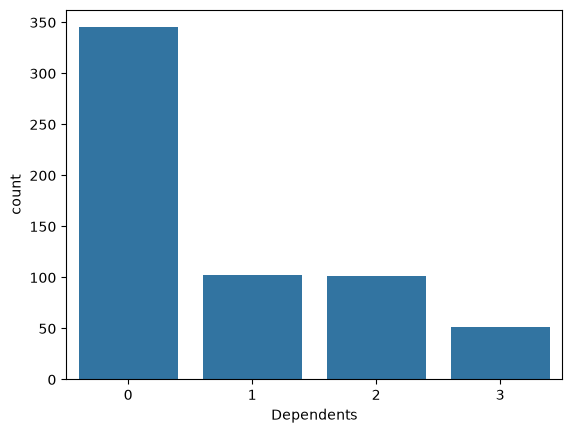

In [27]:
sns.countplot(x='Dependents',data=df)

<Axes: xlabel='Loan_Amount_Term', ylabel='count'>

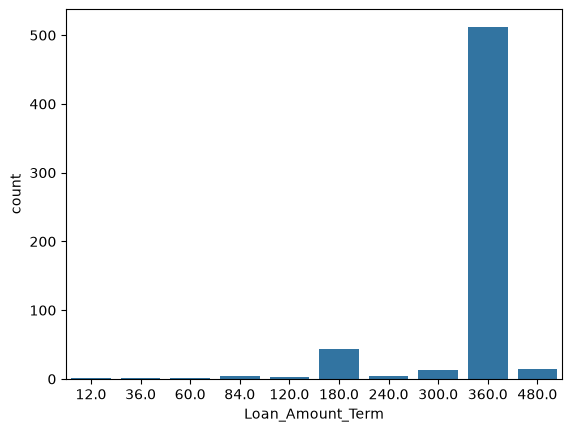

In [28]:
sns.countplot(x='Loan_Amount_Term',data=df)

<Axes: xlabel='Credit_History', ylabel='count'>

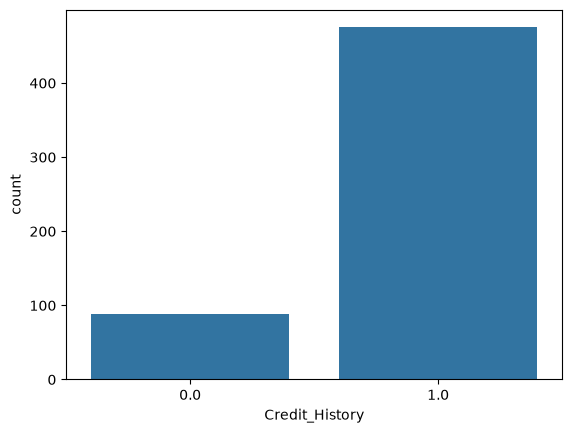

In [29]:
sns.countplot(x='Credit_History',data=df)

Univariate analysis of categorical columns

In [30]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

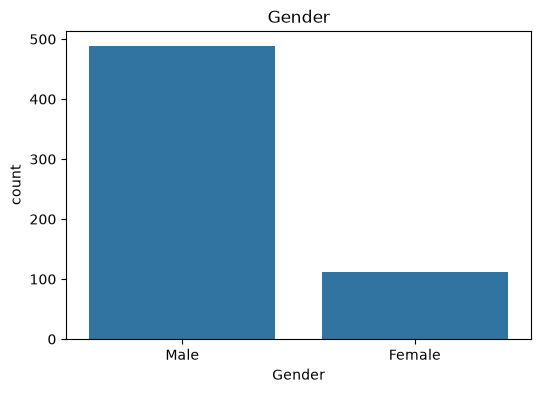

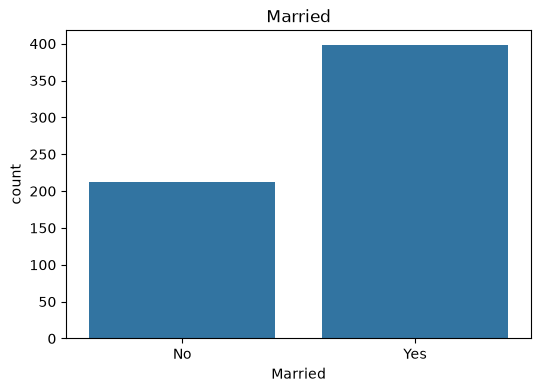

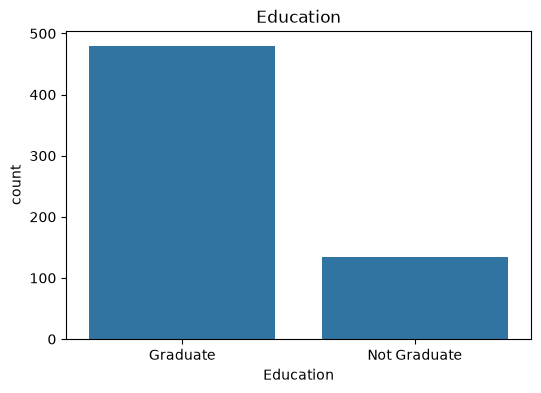

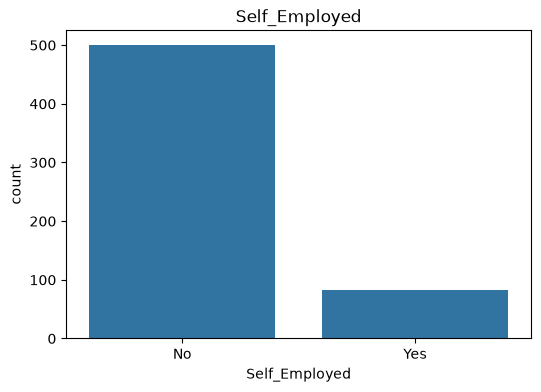

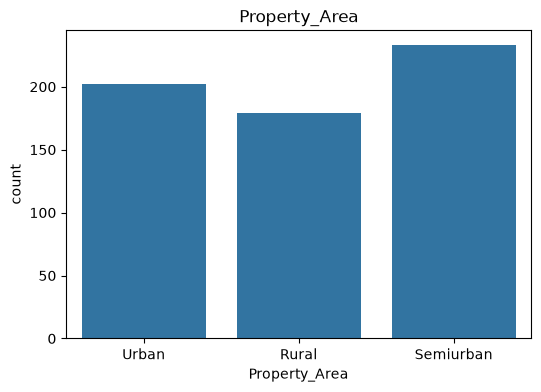

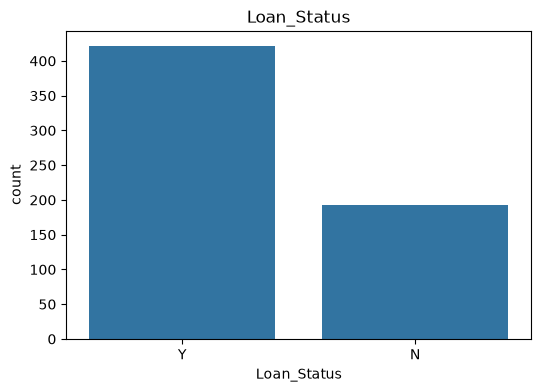

In [31]:
cat_cols=['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']
for columns in cat_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=columns, data=df)
  plt.title(columns)
  plt.show()

In [32]:
percentage = df['Loan_Status'].value_counts(normalize=True) * 100
print(percentage)

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


#Bivariate analysis

<Axes: xlabel='Gender', ylabel='count'>

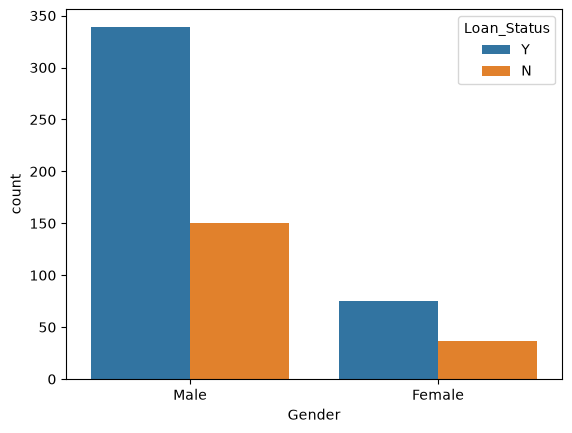

In [33]:
sns.countplot(x='Gender',hue='Loan_Status',data=df)

<Axes: xlabel='Gender', ylabel='Percent'>

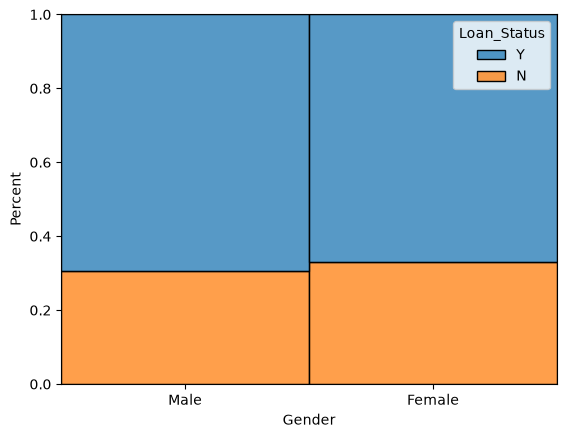

In [34]:
sns.histplot(data=df,x='Gender',hue='Loan_Status',multiple='fill',stat='percent')

In [35]:
pd.crosstab(df['Gender'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


In [36]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

<Axes: xlabel='Gender'>

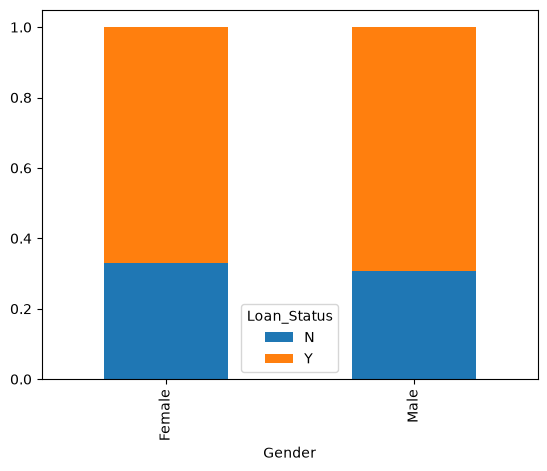

In [37]:
pd.crosstab(df['Gender'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

<Axes: xlabel='Married'>

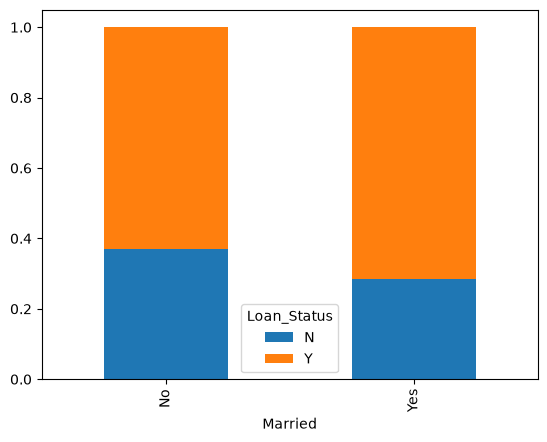

In [38]:
pd.crosstab(df['Married'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [39]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [40]:
df.groupby('Married')['CoapplicantIncome'].mean()

Married
No     1316.558685
Yes    1794.632965
Name: CoapplicantIncome, dtype: float64

In [41]:
df.groupby('Married')['ApplicantIncome'].mean()

Married
No     4970.384977
Yes    5629.173367
Name: ApplicantIncome, dtype: float64

<Axes: xlabel='Education'>

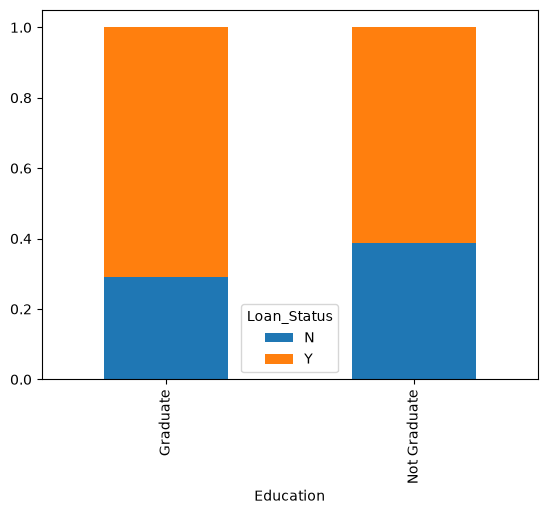

In [42]:
pd.crosstab(df['Education'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [43]:
pd.crosstab(df['Education'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


<Axes: xlabel='Self_Employed'>

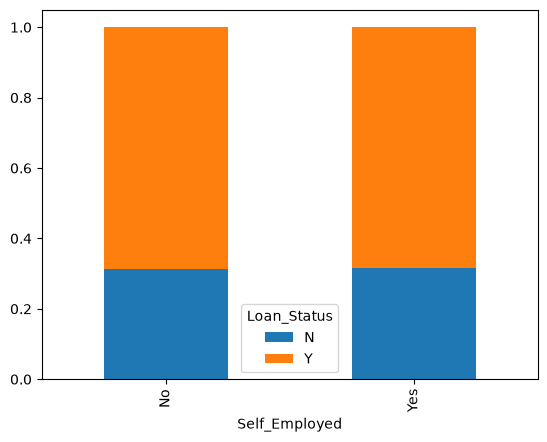

In [44]:
#this column doesnot has any value
pd.crosstab(df['Self_Employed'],df['Loan_Status'],normalize='index').plot(kind='bar',stacked=True)

In [45]:
pd.crosstab(df['Self_Employed'],df['Loan_Status'],normalize='index')*100

Loan_Status,N,Y
Self_Employed,,
No,31.400000,68.600000
Yes,31.707317,68.292683


#Multivariate analysis

<Axes: xlabel='Gender', ylabel='Count'>

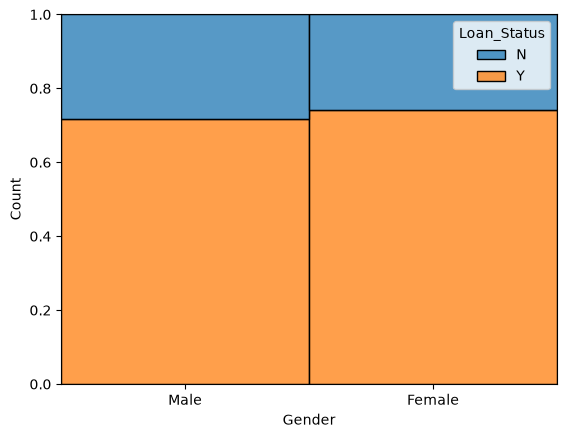

In [46]:
sns.histplot(data=df[df['Married']=='Yes'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Gender', ylabel='Count'>

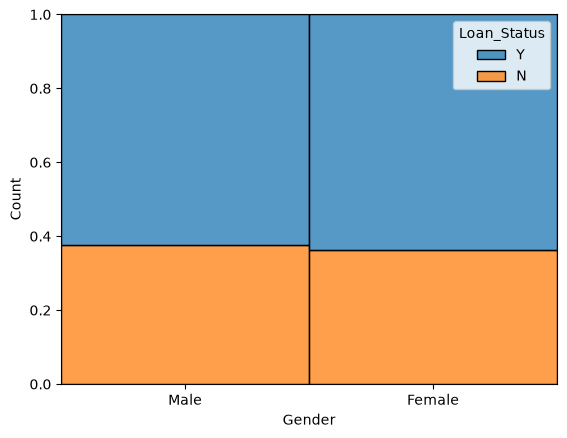

In [47]:
sns.histplot(data=df[df['Married']=='No'], x='Gender',hue='Loan_Status', multiple='fill')

<Axes: xlabel='Education', ylabel='Count'>

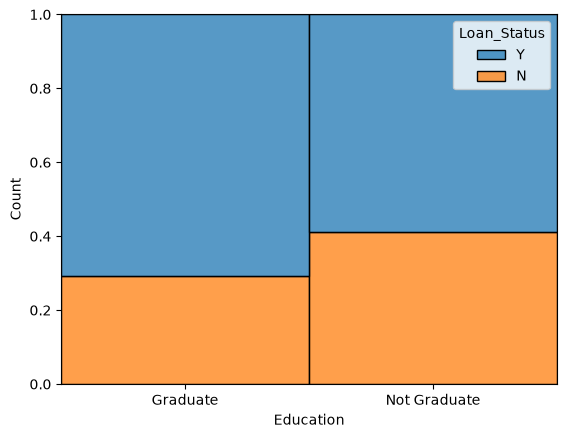

In [48]:
sns.histplot(data=df[df['Self_Employed']=='Yes'], x='Education',hue='Loan_Status', multiple='fill')

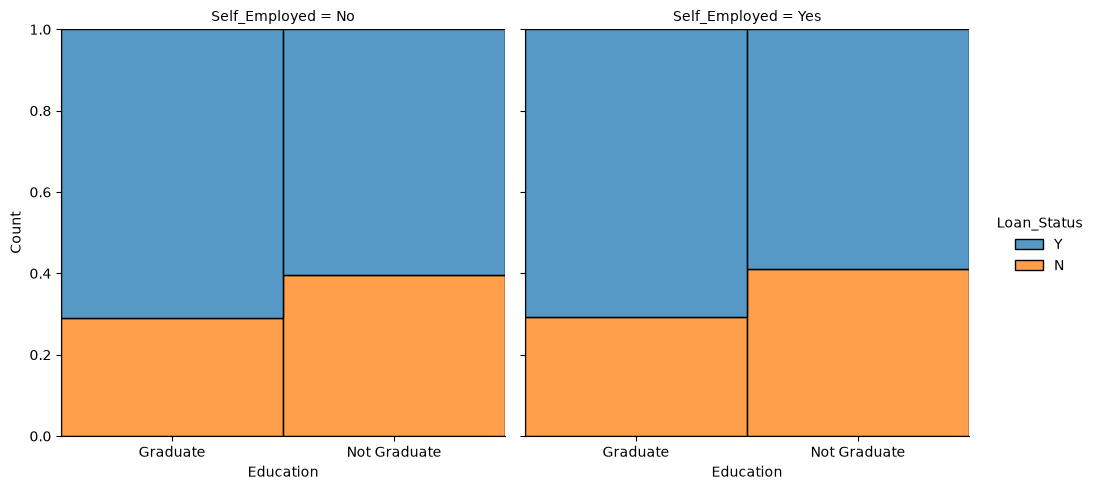

In [49]:
sns.displot(data=df, x='Education',hue='Loan_Status',col='Self_Employed', multiple='fill')

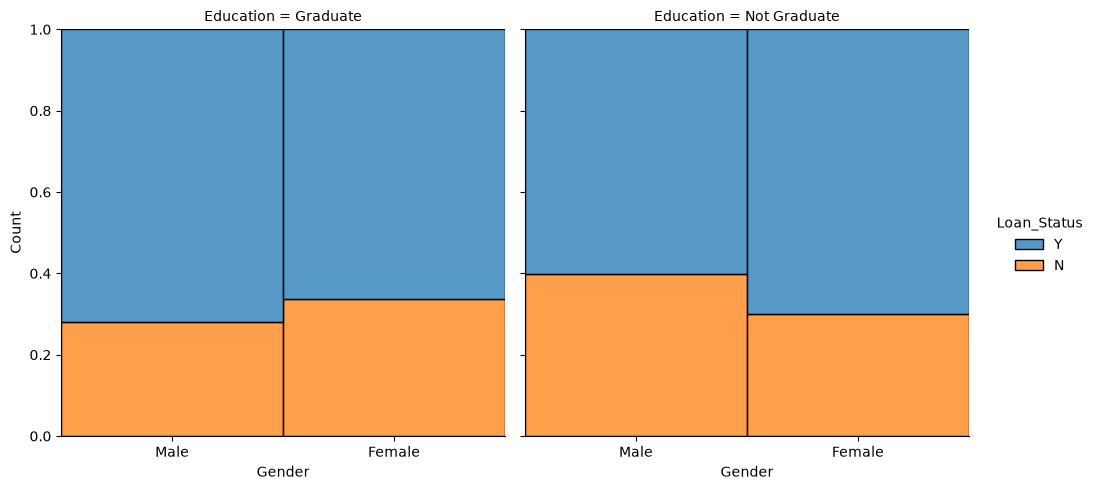

In [50]:
sns.displot(data=df, x='Gender',hue='Loan_Status',col='Education', multiple='fill')

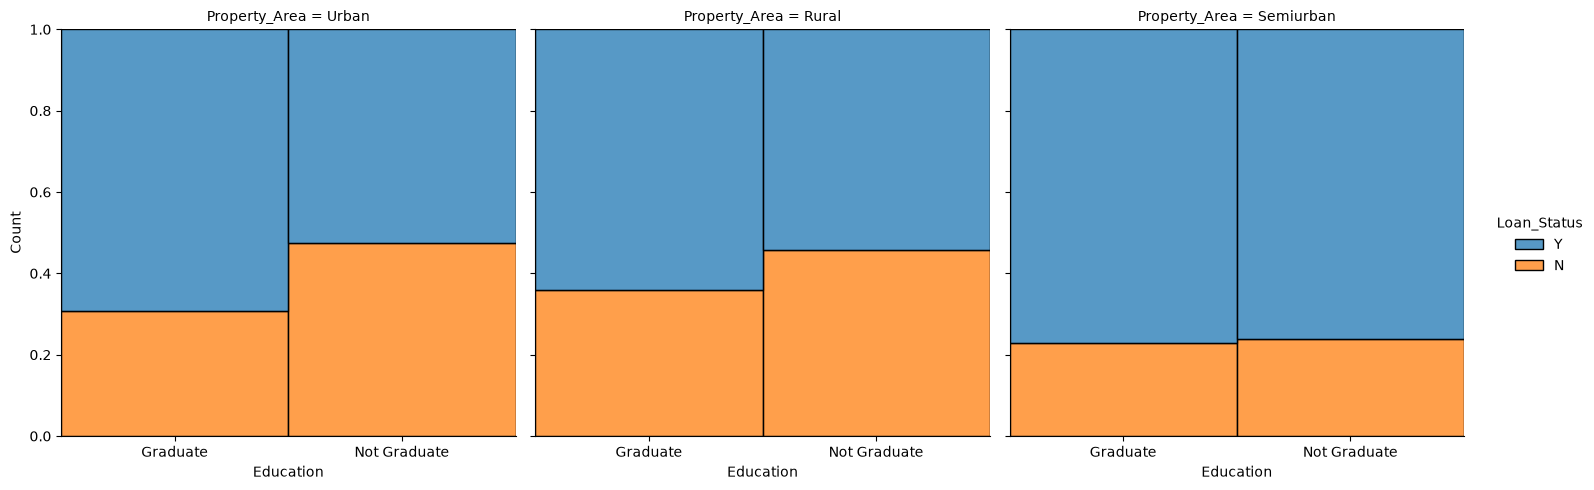

In [51]:
sns.displot(data=df, x='Education',hue='Loan_Status',col='Property_Area', multiple='fill')

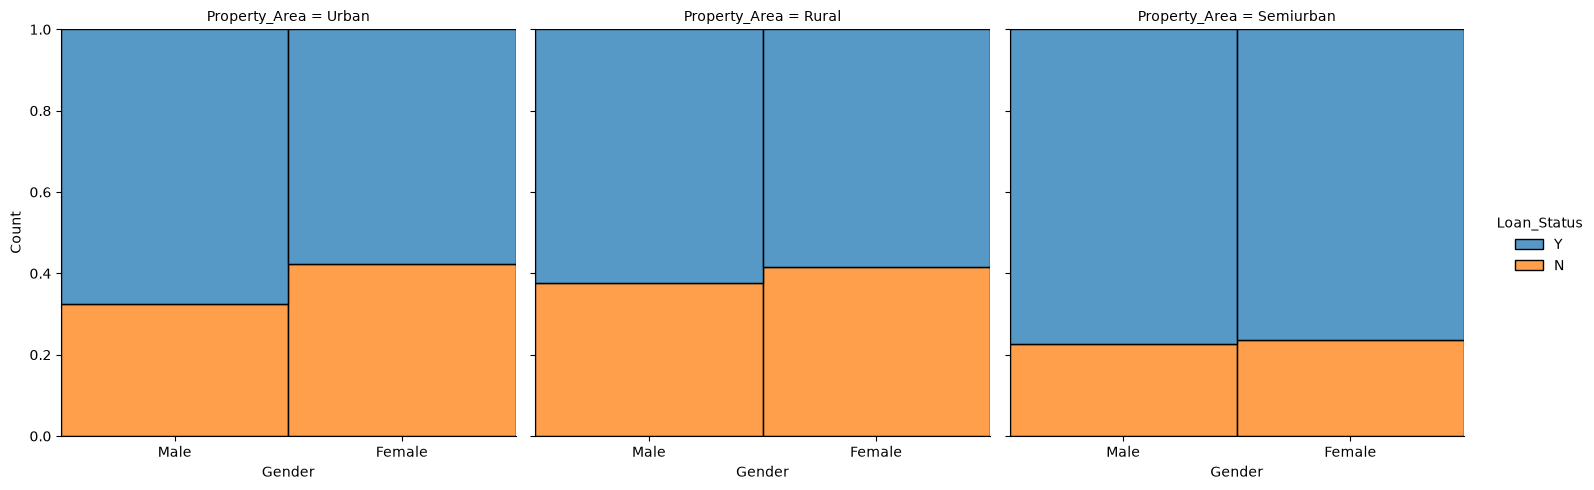

In [52]:
sns.displot(data=df, x='Gender',hue='Loan_Status',col='Property_Area', multiple='fill')

From above all insights ,we can understand that if we are graduate or more qualified then getting loan approval is easy.

#Feature Engineering

In [53]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [54]:
df['Dependents'].unique()

array(['0', '1', '2', 3, nan], dtype=object)

In [55]:
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)

In [56]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [57]:
df['Dependents']=df['Dependents'].astype('int')

In [58]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
126,LP001448,NaN,Yes,3,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y
171,LP001585,NaN,Yes,3,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N


In [59]:
pd.crosstab(df['Dependents'],[df['Married'],df['Gender']],normalize='index')*100

Married            No                  Yes           
Gender         Female       Male    Female       Male
Dependents                                           
0           17.714286  31.714286  5.714286  44.857143
1           12.871287   9.900990  5.940594  71.287129
2            2.020202   6.060606  5.050505  86.868687
3            6.250000   6.250000  0.000000  87.500000

In [60]:
mode_gender_3D_Y=df.loc[(df['Married']=="Yes")&(df['Dependents']==3),'Gender'].mode()[0]

In [61]:
mode_gender_3D_Y

'Male'

In [62]:
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==3),"Gender"] = mode_gender_3D_Y

In [63]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
23,LP001050,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
188,LP001644,NaN,Yes,0,Graduate,Yes,674,5296.0,168.0,360.0,1.0,Rural,Y
314,LP002024,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural,N
334,LP002103,NaN,Yes,1,Graduate,Yes,9833,1833.0,182.0,180.0,1.0,Urban,Y
460,LP002478,NaN,Yes,0,Graduate,Yes,2083,4083.0,160.0,360.0,NaN,Semiurban,Y
467,LP002501,NaN,Yes,0,Graduate,No,16692,0.0,110.0,360.0,1.0,Semiurban,Y
477,LP002530,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban,N
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
576,LP002872,NaN,Yes,0,Graduate,No,3087,2210.0,136.0,360.0,0.0,Semiurban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y


In [64]:
mode_gender_2D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==2),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==2),"Gender"] = mode_gender_2D_Y

mode_gender_1D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==1),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==1),"Gender"] = mode_gender_1D_Y

mode_gender_0D_Y = df.loc[(df['Married']=="Yes")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='Yes')&(df['Dependents']==0),"Gender"] = mode_gender_0D_Y

In [65]:
df.isna().sum()

Loan_ID               0
Gender                3
Married               3
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [66]:
df[df['Gender'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
507,LP002625,NaN,No,0,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
588,LP002925,NaN,No,0,Graduate,No,4750,0.0,94.0,360.0,1.0,Semiurban,Y
592,LP002933,NaN,No,3,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y


In [67]:
mode_gender_3D_N = df.loc[(df['Married']=="No")&(df['Dependents']==3),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==3),"Gender"] = mode_gender_3D_N

mode_gender_0D_N = df.loc[(df['Married']=="No")&(df['Dependents']==0),"Gender"].mode()[0]
df.loc[(df['Gender'].isnull())&(df['Married']=='No')&(df['Dependents']==0),"Gender"] = mode_gender_0D_N

In [68]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               3
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [69]:
df[df['Married'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,0,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,0,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,0,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [70]:
df.loc[104,'Married'] = 'Yes'
df.loc[228,'Married'] = 'No'
df.loc[435,'Married'] = 'No'

In [71]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [72]:
df[df['Self_Employed'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
19,LP001041,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
24,LP001052,Male,Yes,1,Graduate,NaN,3717,2925.0,151.0,360.0,NaN,Semiurban,N
29,LP001087,Female,No,2,Graduate,NaN,3750,2083.0,120.0,360.0,1.0,Semiurban,Y
30,LP001091,Male,Yes,1,Graduate,NaN,4166,3369.0,201.0,360.0,NaN,Urban,N
95,LP001326,Male,No,0,Graduate,NaN,6782,0.0,NaN,360.0,NaN,Urban,N
107,LP001370,Male,No,0,Not Graduate,NaN,7333,0.0,120.0,360.0,1.0,Rural,N
111,LP001387,Female,Yes,0,Graduate,NaN,2929,2333.0,139.0,360.0,1.0,Semiurban,Y
114,LP001398,Male,No,0,Graduate,NaN,5050,0.0,118.0,360.0,1.0,Semiurban,Y
158,LP001546,Male,No,0,Graduate,NaN,2980,2083.0,120.0,360.0,1.0,Rural,Y


In [73]:
high_income=df['ApplicantIncome'].median()
high_income

np.float64(3812.5)

In [74]:
df.loc[(df['Self_Employed'].isnull())&(df['ApplicantIncome']>high_income),"Self_Employed"]="Yes"

In [75]:
df['Self_Employed']=df['Self_Employed'].fillna('No')

In [76]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [77]:
df[df['LoanAmount'].isna()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
35,LP001106,Male,Yes,0,Graduate,No,2275,2067.0,NaN,360.0,1.0,Urban,Y
63,LP001213,Male,Yes,1,Graduate,No,4945,0.0,NaN,360.0,0.0,Rural,N
81,LP001266,Male,Yes,1,Graduate,Yes,2395,0.0,NaN,360.0,1.0,Semiurban,Y
95,LP001326,Male,No,0,Graduate,Yes,6782,0.0,NaN,360.0,NaN,Urban,N
102,LP001350,Male,Yes,0,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,Y
103,LP001356,Male,Yes,0,Graduate,No,4652,3583.0,NaN,360.0,1.0,Semiurban,Y
113,LP001392,Female,No,1,Graduate,Yes,7451,0.0,NaN,360.0,1.0,Semiurban,Y
127,LP001449,Male,No,0,Graduate,No,3865,1640.0,NaN,360.0,1.0,Rural,Y
202,LP001682,Male,Yes,3,Not Graduate,No,3992,0.0,NaN,180.0,1.0,Urban,N


In [78]:
df['TotalIncome']=df['ApplicantIncome']+df['CoapplicantIncome']

In [79]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0


In [80]:
df["IncomeBand"], income_bins = pd.qcut(df['TotalIncome'], 4, labels=False,retbins=True)

In [81]:
print(income_bins)

[ 1442.    4166.    5416.5   7521.75 81000.  ]


In [82]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [83]:
df['LoanAmount']=df['LoanAmount'].fillna(df.groupby('IncomeBand')['LoanAmount'].transform('median'))

In [84]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
IncomeBand            0
dtype: int64

In [85]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df.groupby("IncomeBand")["Loan_Amount_Term"].transform(lambda x:x.mode()[0]))

In [86]:
df.isna().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
IncomeBand            0
dtype: int64

In [87]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2


In [88]:
df['Credit_History'].unique()

array([ 1.,  0., nan])

In [89]:
df['Credit_History']=df['Credit_History'].fillna(2)

In [90]:
df['Credit_History'].unique()

array([1., 0., 2.])

In [91]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
IncomeBand           0
dtype: int64

In [92]:
df['LoanIncomeRatio'] = df['LoanAmount']/df['TotalIncome']

In [93]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500


In [94]:
df['HasCoapplicant'] = np.where(df['CoapplicantIncome'] > 0,1,0)

In [95]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,5849,0.0,141.0,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

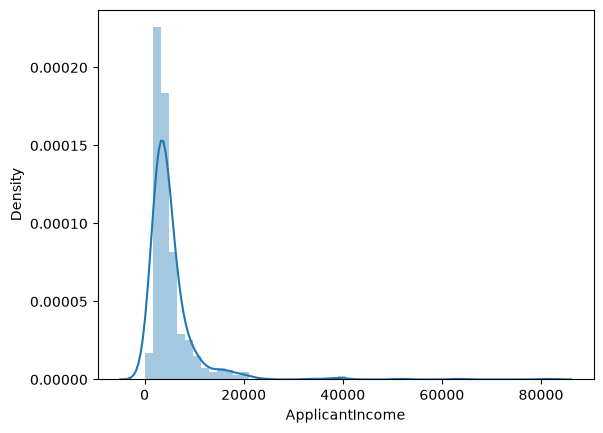

In [96]:
sns.distplot(df['ApplicantIncome'])

In [97]:
df['ApplicantIncome'] = np.log1p(df['ApplicantIncome'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\2349853404.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ApplicantIncome'])


<Axes: xlabel='ApplicantIncome', ylabel='Density'>

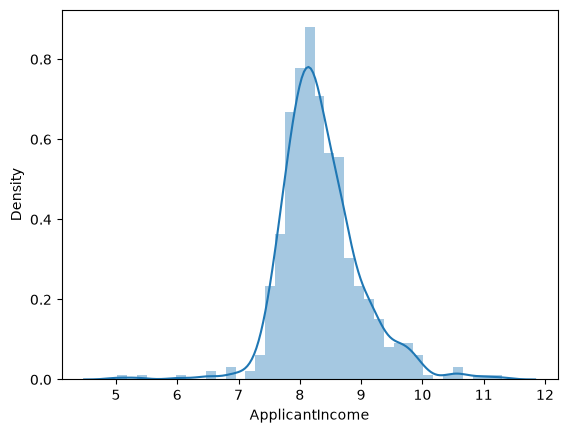

In [98]:
sns.distplot(df['ApplicantIncome'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

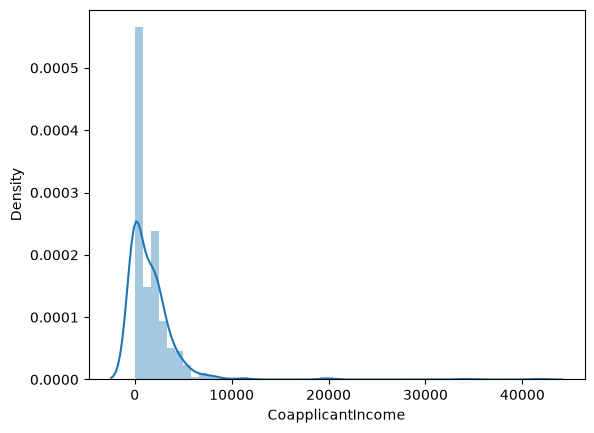

In [99]:
sns.distplot(df['CoapplicantIncome'])

In [100]:
df['CoapplicantIncome'] = np.log1p(df['CoapplicantIncome'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\2149142820.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CoapplicantIncome'])


<Axes: xlabel='CoapplicantIncome', ylabel='Density'>

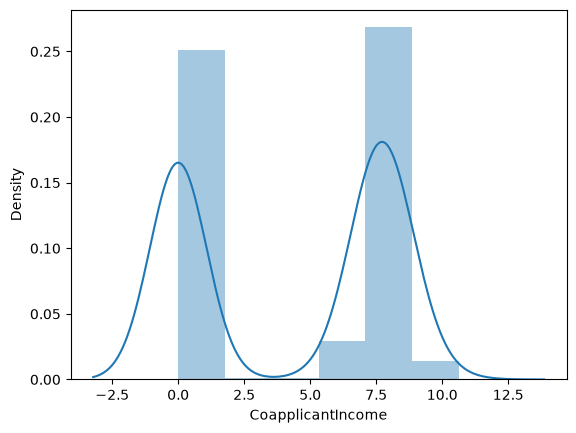

In [101]:
sns.distplot(df['CoapplicantIncome'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

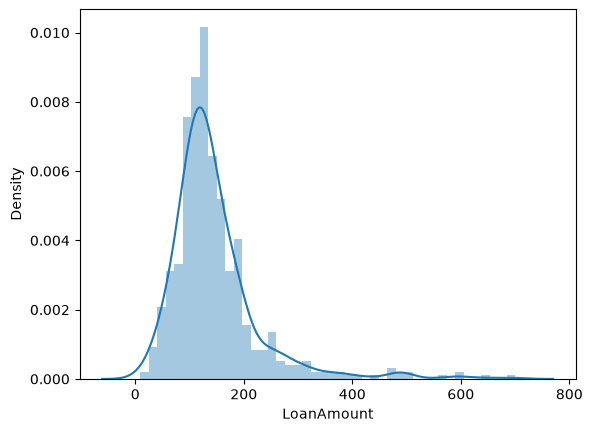

In [102]:
sns.distplot(df['LoanAmount'])

In [103]:
df['LoanAmount'] = np.log1p(df['LoanAmount'])

C:\Users\Saumya\AppData\Local\Temp\ipykernel_9240\413488336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['LoanAmount'])


<Axes: xlabel='LoanAmount', ylabel='Density'>

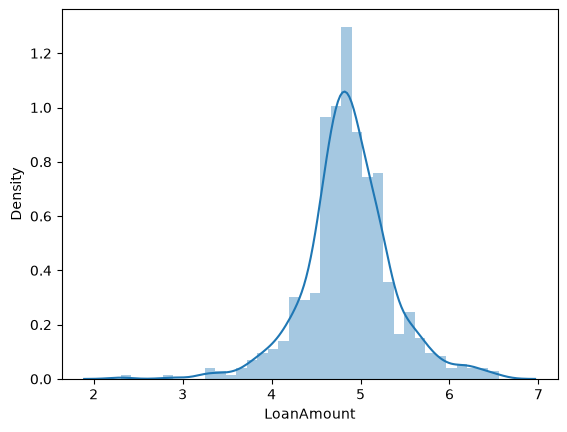

In [104]:
sns.distplot(df['LoanAmount'])

In [105]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,LP001002,Male,No,0,Graduate,No,8.674197,0.000000,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0
1,LP001003,Male,Yes,1,Graduate,No,8.430327,7.319202,4.859812,360.0,1.0,Rural,N,6091.0,2,0.021015,1
2,LP001005,Male,Yes,0,Graduate,Yes,8.006701,0.000000,4.204693,360.0,1.0,Urban,Y,3000.0,0,0.022000,0
3,LP001006,Male,Yes,0,Not Graduate,No,7.857094,7.765993,4.795791,360.0,1.0,Urban,Y,4941.0,1,0.024287,1
4,LP001008,Male,No,0,Graduate,No,8.699681,0.000000,4.955827,360.0,1.0,Urban,Y,6000.0,2,0.023500,0


In [106]:
df.drop('Loan_ID',axis=1,inplace=True)

In [107]:
df.dtypes

Gender                object
Married               object
Dependents             int64
Education             object
Self_Employed         object
ApplicantIncome      float64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
TotalIncome          float64
IncomeBand             int64
LoanIncomeRatio      float64
HasCoapplicant         int64
dtype: object

In [108]:
cat_cols = [column for column in df.columns if df[column].dtypes == 'O']

In [109]:
cat_cols

['Gender',
 'Married',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [110]:
target_col = "Loan_Status"
if target_col in cat_cols:
    cat_cols.remove(target_col)

In [111]:
df[cat_cols]

,Gender,Married,Education,Self_Employed,Property_Area
0,Male,No,Graduate,No,Urban
1,Male,Yes,Graduate,No,Rural
2,Male,Yes,Graduate,Yes,Urban
3,Male,Yes,Not Graduate,No,Urban
4,Male,No,Graduate,No,Urban
...,...,...,...,...,...
609,Female,No,Graduate,No,Rural
610,Male,Yes,Graduate,No,Rural
611,Male,Yes,Graduate,No,Urban
612,Male,Yes,Graduate,No,Urban


In [112]:
from sklearn.preprocessing import OneHotEncoder

In [113]:
ohe = OneHotEncoder(drop="first", sparse_output=False)

In [114]:
encoded_data = ohe.fit_transform(df[cat_cols])

In [115]:
encoded_data

array([[1., 0., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 0., 1.],
       ...,
       [1., 1., 0., 0., 0., 1.],
       [1., 1., 0., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.]], shape=(614, 6))

In [116]:
encoded_df = pd.DataFrame(encoded_data,columns = ohe.get_feature_names_out(cat_cols), index=df.index)

In [117]:
encoded_df

,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,1.0,0.0,0.0,0.0,0.0,1.0
1,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,1.0,0.0,1.0,0.0,1.0
3,1.0,1.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
609,0.0,0.0,0.0,0.0,0.0,0.0
610,1.0,1.0,0.0,0.0,0.0,0.0
611,1.0,1.0,0.0,0.0,0.0,1.0
612,1.0,1.0,0.0,0.0,0.0,1.0


In [118]:
df.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant
0,Male,No,0,Graduate,No,8.674197,0.0,4.955827,360.0,1.0,Urban,Y,5849.0,2,0.024107,0


In [119]:
df = pd.concat([df,encoded_df],axis=1)

In [120]:
df.drop(columns=cat_cols,axis=1,inplace=True)

In [121]:
df.head(10)

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,8.674197,0.000000,4.955827,360.0,1.0,Y,5849.0,2,0.024107,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,8.430327,7.319202,4.859812,360.0,1.0,N,6091.0,2,0.021015,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,8.006701,0.000000,4.204693,360.0,1.0,Y,3000.0,0,0.022000,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,7.857094,7.765993,4.795791,360.0,1.0,Y,4941.0,1,0.024287,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,8.699681,0.000000,4.955827,360.0,1.0,Y,6000.0,2,0.023500,0,1.0,0.0,0.0,0.0,0.0,1.0
5,2,8.597482,8.342125,5.590987,360.0,1.0,Y,9613.0,3,0.027775,1,1.0,1.0,0.0,1.0,0.0,1.0
6,0,7.755339,7.324490,4.564348,360.0,1.0,Y,3849.0,0,0.024682,1,1.0,1.0,1.0,0.0,0.0,1.0
7,3,8.018625,7.826044,5.068904,360.0,0.0,N,5540.0,2,0.028520,1,1.0,1.0,0.0,0.0,1.0,0.0
8,2,8.295798,7.331060,5.129899,360.0,1.0,Y,5532.0,2,0.030369,1,1.0,1.0,0.0,0.0,0.0,1.0
9,1,9.460476,9.302828,5.857933,360.0,1.0,N,23809.0,3,0.014658,1,1.0,1.0,0.0,0.0,1.0,0.0


In [122]:
#scaling- do all the columns into same range
# scaling only applicable to
from sklearn.preprocessing import StandardScaler

In [123]:
scaling_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','TotalIncome','LoanIncomeRatio']

In [124]:
scaler = StandardScaler()
df[scaling_cols]= scaler.fit_transform(df[scaling_cols])

In [125]:
df.head()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,Y,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,N,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,Y,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,Y,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,Y,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0


In [126]:
X = df.drop("Loan_Status",axis=1)
y =df["Loan_Status"]

In [127]:
X

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,TotalIncome,IncomeBand,LoanIncomeRatio,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,0.516186,-1.107783,0.180177,0.273231,1.0,-0.182184,2,0.034587,0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.137806,0.782158,-0.014813,0.273231,1.0,-0.144684,2,-0.336243,1,1.0,1.0,0.0,0.0,0.0,0.0
2,0,-0.519479,-1.107783,-1.345255,0.273231,1.0,-0.623656,0,-0.218066,0,1.0,1.0,0.0,1.0,0.0,1.0
3,0,-0.751605,0.897526,-0.144831,0.273231,1.0,-0.322885,1,0.056162,1,1.0,1.0,1.0,0.0,0.0,1.0
4,0,0.555727,-1.107783,0.180177,0.273231,1.0,-0.158785,2,-0.038172,0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,-0.572062,-1.107783,-1.199088,0.273231,1.0,-0.639152,0,0.079689,0,0.0,0.0,0.0,0.0,0.0,0.0
610,3,-0.032679,-1.107783,-2.342641,-2.522836,1.0,-0.452274,0,-1.688178,0,1.0,1.0,0.0,0.0,0.0,0.0
611,1,1.015921,0.308483,1.361123,0.273231,1.0,0.199475,3,0.793887,1,1.0,1.0,0.0,0.0,0.0,1.0
612,2,0.918972,-1.107783,0.750060,0.273231,1.0,0.086512,3,0.100996,0,1.0,1.0,0.0,0.0,0.0,1.0


In [128]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: object

In [129]:
#from sklearn.feature_selection import SelectKBest, mutual_info_classif
#selector = SelectKBest(mutual_info_classif,k=8)

In [130]:
#X_new = selector.fit_transform(X,y)

In [131]:
#X.columns[selector.get_support()]

In [132]:
#split into train and test dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state =42,stratify =y)

In [133]:
X_train.columns

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'TotalIncome', 'IncomeBand',
       'LoanIncomeRatio', 'HasCoapplicant', 'Gender_Male', 'Married_Yes',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

#Model selection

In [134]:
rf =RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [135]:
y_pred= rf.predict(X_test)

In [136]:
accuracy_score(y_test,y_pred)

0.8943089430894309

In [137]:
confusion_matrix(y_test,y_pred)

array([[29,  9],
       [ 4, 81]])

In [138]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           N       0.88      0.76      0.82        38
           Y       0.90      0.95      0.93        85

    accuracy                           0.89       123
   macro avg       0.89      0.86      0.87       123
weighted avg       0.89      0.89      0.89       123



In [139]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators':[100,200,300,500],
    'max_depth': [None, 5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features':['sqrt','log2'],
    'bootstrap':[True,False]
}

In [140]:
random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state=42),
    param_distributions= param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)

In [141]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretur

In [142]:
random_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'max_depth': 10,
 'bootstrap': True}

In [143]:
random_search.best_score_

np.float64(0.7963512677798392)

In [144]:
random_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [145]:
best_rf_model = random_search.best_estimator_

In [146]:
y_pred_tuned = best_rf_model.predict(X_test)

In [147]:
accuracy_score(y_test,y_pred_tuned)

0.8943089430894309

In [148]:
import joblib

In [149]:
# Path.cwd() /'..'/'data'/'train_loan.csv'
model_path = Path.cwd() /'..'/'utils'/'loan_rf_model.pkl'
joblib.dump(best_rf_model, model_path)

['e:\\IIT Palakad-AIML advanced executive program\\Loan Analysis\\notebooks\\..\\utils\\loan_rf_model.pkl']

In [150]:
scaler_path =  Path.cwd() /'..'/'utils'/'scaler.pkl'
joblib.dump(scaler, scaler_path)

['e:\\IIT Palakad-AIML advanced executive program\\Loan Analysis\\notebooks\\..\\utils\\scaler.pkl']

In [151]:
OHE_path = Path.cwd() /'..'/'utils'/'onehot_encoder.pkl'
joblib.dump(ohe, OHE_path)

['e:\\IIT Palakad-AIML advanced executive program\\Loan Analysis\\notebooks\\..\\utils\\onehot_encoder.pkl']

In [154]:
model_cols_path = Path.cwd() /'..'/'utils'/'model_columns.pkl'
scaling_path = Path.cwd() /'..'/'utils'/'scaling_cols.pkl'

joblib.dump(X.columns.tolist(), model_cols_path)
joblib.dump(scaling_cols, scaling_path)

['e:\\IIT Palakad-AIML advanced executive program\\Loan Analysis\\notebooks\\..\\utils\\scaling_cols.pkl']